In [1]:
import numpy as np
import geopandas as gpd
from pathlib import Path
import pandas as pd
import torch
from sklearn.neighbors import kneighbors_graph
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric_temporal.nn.recurrent import A3TGCN2
from torch_geometric_temporal.signal import temporal_signal_split

c:\Users\rqg886\Desktop\geospatial-regression\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
INPUT_DIR = Path("data/raw")
OUT_DIR = Path("data/interim")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.concat(
    [pd.read_csv(f, low_memory=False) for f in INPUT_DIR.glob("*citibike-tripdata*.csv")],
    ignore_index=True,
)


In [3]:
stations = (
    df[["start_station_id", "start_station_name", "start_lat", "start_lng"]]
    .dropna()
    .drop_duplicates(subset="start_station_id")
    .rename(columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng",
    })
    .reset_index(drop=True)
)

stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["lng"], stations["lat"]),
    crs="EPSG:4326",
)
stations_gdf.head()

,station_id,station_name,lat,lng,geometry
0,5679.05,Mercer St & Bleecker St,40.727064,-73.996621,POINT (-73.99662 40.72706)
1,6319.01,45 Rd & 11 St,40.747086,-73.949772,POINT (-73.94977 40.74709)
2,6465.04,95 St & 35 Ave,40.753010,-73.872660,POINT (-73.87266 40.75301)
3,3739.06,4 Ave & 17 St,40.665507,-73.993037,POINT (-73.99304 40.66551)
4,7767.06,Southern Blvd & Ave St John,40.812769,-73.901583,POINT (-73.90158 40.81277)


In [4]:
stations_gdf.station_id.nunique()

2267

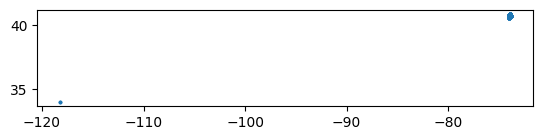

In [5]:
stations_gdf.plot(markersize=3);

In [6]:
coords = stations_gdf[["lat", "lng"]].values

# build a k-nearest-neighbors graph 
adj = kneighbors_graph(coords, n_neighbors=5, mode="connectivity")
adj = adj.tocoo()

# Convert to PyG format. edge_index is shape (2, num_edges)
edge_index = torch.tensor(np.vstack([adj.row, adj.col]), dtype=torch.long)

In [7]:
edge_index.shape

torch.Size([2, 11335])

In [12]:
class TemporalGNN(torch.nn.Module):
    def __init__(self, node_features, periods, batch_size):
        super(TemporalGNN, self).__init__()
        # Attention Temporal Graph Convolutional Cell
        # out_channels is the hidden embedding dimension per node after the graph conv + temporal attention
        self.tgnn = A3TGCN2(in_channels=node_features,  out_channels=32, periods=periods,batch_size=batch_size) # node_features=2, periods=12
        # Equals single-shot prediction
        self.linear = torch.nn.Linear(32, periods)

    def forward(self, x, edge_index):
        """
        x = Node features for T time steps
        edge_index = Graph edge indices
        """
        h = self.tgnn(x, edge_index) # x [b, 207, 2, 12]  returns h [b, 207, 12]
        h = F.relu(h) 
        h = self.linear(h)
        return h

In [13]:
# Create model and optimizers
# periods = 24 indicates that 24h in, 24h out
model = TemporalGNN(node_features=2, periods=24, batch_size=2).to("cpu")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss()


print('Net\'s state_dict:')
total_param = 0
for param_tensor in model.state_dict():
    print(param_tensor, '\t', model.state_dict()[param_tensor].size())
    total_param += np.prod(model.state_dict()[param_tensor].size())
print('Net\'s total params:', total_param)
#--------------------------------------------------
print('Optimizer\'s state_dict:')
for var_name in optimizer.state_dict():
    print(var_name, '\t', optimizer.state_dict()[var_name])

Net's state_dict:
tgnn._attention 	 torch.Size([24])
tgnn._base_tgcn.conv_z.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_z.lin.weight 	 torch.Size([32, 2])
tgnn._base_tgcn.linear_z.weight 	 torch.Size([32, 64])
tgnn._base_tgcn.linear_z.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_r.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_r.lin.weight 	 torch.Size([32, 2])
tgnn._base_tgcn.linear_r.weight 	 torch.Size([32, 64])
tgnn._base_tgcn.linear_r.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_h.bias 	 torch.Size([32])
tgnn._base_tgcn.conv_h.lin.weight 	 torch.Size([32, 2])
tgnn._base_tgcn.linear_h.weight 	 torch.Size([32, 64])
tgnn._base_tgcn.linear_h.bias 	 torch.Size([32])
linear.weight 	 torch.Size([24, 32])
linear.bias 	 torch.Size([24])
Net's total params: 7344
Optimizer's state_dict:
state 	 {}
param_groups 	 [{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': Non

In [ ]:
# model's expected shape: (B, N, F, T_in)
# the graph (edge_index) is shared across all batches, and not loaded per sample
# for each timestep "t":
# x = the last T_in hours: shape (N, F=1, T_in)
# y = the next T_out hours: shape (N, T_out)

In [ ]:
model.train() # puts model in train mode

for epoch in range(1):
    step = 0
    loss_list = []
    for encoder_inputs, labels in train_loader:
        y_hat = model(encoder_inputs, static_edge_index)         # Get model predictions
        loss = loss_fn(y_hat, labels) # Mean squared error #loss = torch.mean((y_hat-labels)**2)  sqrt to change it to rmse
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        step= step+ 1
        loss_list.append(loss.item())
        if step % 100 == 0 :
            print(sum(loss_list)/len(loss_list))
    print("Epoch {} train RMSE: {:.4f}".format(epoch, sum(loss_list)/len(loss_list)))